## Topic 3: Embedding Layer and Word Embeddings

### 1. Introduction
In the previous topic, we converted words to integers (e.g., "India" → 3). However, these integers are arbitrary—they don't capture any meaning or relationship between words. For example, "India" being 3 and "win" being 5 doesn't tell us that these words might be related in a sentence.

**Word Embeddings** solve this problem by representing each word as a **dense vector** (a list of numbers) where words with similar meanings have similar vectors. The **Embedding Layer** in Keras learns these vectors automatically during training.

In real life, embeddings are used in:
- Search engines (understanding query intent)
- Recommendation systems (finding similar products)
- Chatbots (understanding user messages)
- Any NLP task where word meaning matters

### 2. Detailed Explanation

**The Problem with Simple Integer Encoding:**

Consider two reviews:
- Review 1: "Good movie" → [1, 2]
- Review 2: "Bad movie" → [3, 2]

The integer 1 (Good) and 3 (Bad) are just numbers. The network doesn't know they are opposites. Also, if you pad, you add zeros which don't carry any meaning.

**What is an Embedding?**

An embedding is a **dense vector representation** of a word. For example:
- "Good" might be represented as `[0.82, -0.15, 0.34]` (3-dimensional vector)
- "Bad" might be `[-0.79, 0.22, -0.41]` (3-dimensional vector)
- Both are 3 numbers (dense, not sparse), and their similarity can be measured.

**Key Properties of Embeddings:**
- **Dense:** Most values are non-zero (unlike one-hot encoding where most values are zero).
- **Low-dimensional:** Instead of having a dimension equal to vocabulary size (e.g., 10,000), you choose a smaller dimension (e.g., 32, 64, 128, 300).
- **Semantic:** Words with similar meanings are closer in the vector space. For example, "king" and "queen" would have similar vectors.
- **Learned:** The embedding vectors are learned during training based on your specific dataset.

**How the Embedding Layer Works:**

1. You provide the integer-encoded sequences as input.
2. The Embedding Layer has a weight matrix of shape `(vocabulary_size, embedding_dimension)`.
3. For each integer input (say 3), it looks up row 3 of the weight matrix and returns that vector.
4. These vectors are then fed into the RNN.

> **Analogy:** Think of a lookup table. Each word (integer) has its own row in the table. When you give the integer, the table gives you back the corresponding vector. During training, the numbers in the table are adjusted to capture meaning.

**Comparison: One-Hot Encoding vs. Embedding**

| Feature | One-Hot Encoding | Embedding |
|---------|------------------|-----------|
| Representation | Sparse (mostly zeros) | Dense (all non-zero) |
| Dimension | = Vocabulary size (e.g., 10,000) | Small (e.g., 32, 64, 300) |
| Meaning | No semantic meaning | Captures semantic relationships |
| Learnable | No (fixed) | Yes (learned during training) |
| Memory | High | Low |

**Why Embeddings Give Better Results:**
- They reduce dimensionality (faster training).
- They capture relationships (e.g., "good" and "great" will be close).
- They are learned specifically on your data, so they understand context.
- They handle out-of-vocabulary words better when pre-trained embeddings are used.

### 3. Key Points
- **Embedding Layer** converts integer indices to dense vectors.
- **Dense representation** means most values are non-zero.
- Embeddings capture **semantic meaning**—similar words have similar vectors.
- You specify **input_dim** (vocabulary size), **output_dim** (vector size), and **input_length** (sequence length).
- Embeddings can be **learned from scratch** during training or **pre-trained** (Word2Vec, GloVe).
- Learning embeddings specific to your data often gives the best results.

### 4. Syntax/Structure (Keras Implementation)

```python
from keras.models import Sequential
from keras.layers import Embedding

model = Sequential()

# Adding an Embedding Layer
model.add(Embedding(
    input_dim=10000,      # Vocabulary size (total unique words)
    output_dim=32,         # Dimension of the dense vector
    input_length=50        # Length of each sequence (number of words per review)
))
```

- **`input_dim`:** The total number of unique words in your vocabulary. Must be equal to (or greater than) the maximum index in your input data. If you used `Tokenizer(num_words=10000)`, this should be 10000.
- **`output_dim`:** The size of the dense vector. Typical values: 32, 64, 128, 300. Larger values capture more nuance but require more data and computation.
- **`input_length`:** The length of your sequences after padding. Every input sequence must have exactly this length.

**What Happens Internally:**
- The layer creates a weight matrix of shape `(input_dim, output_dim)`.
- When you pass a sequence `[1, 5, 3, 0, 2]`, it looks up rows 1, 5, 3, 0, 2 in the weight matrix.
- It outputs a sequence of vectors: `[vector_for_1, vector_for_5, vector_for_3, vector_for_0, vector_for_2]`.
- The output shape is `(batch_size, input_length, output_dim)`.

### 5. Code Examples

**Simple Example: Showing How Embedding Works**
```python
from keras.models import Sequential
from keras.layers import Embedding
import numpy as np

# Sample data: 2 reviews, each with 5 words, vocabulary size = 17
dummy_input = np.array([
    [1, 2, 3, 4, 5],   # Review 1
    [6, 7, 8, 9, 10]   # Review 2
])

# Create model with embedding layer
model = Sequential()
model.add(Embedding(input_dim=17, output_dim=2, input_length=5))

# Get the embedding vectors
output = model.predict(dummy_input)
print("Output shape:", output.shape)
print("Embedding for first word of first review:", output[0, 0, :])
print("Embedding for second word of first review:", output[0, 1, :])
```

**Output:**
```
Output shape: (2, 5, 2)
Embedding for first word of first review: [0.034, -0.021]
Embedding for second word of first review: [0.045, 0.008]
```
*Note: The actual numbers will be random because the model is not trained yet.*

**Complete Sentiment Analysis with Embedding (from transcript):**
```python
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=10000, output_dim=32, input_length=50))

# RNN layer
model.add(SimpleRNN(units=32, return_sequences=False))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary
model.summary()
```

**Understanding the Parameters (from transcript):**
In the example above, the total parameters are:
- Embedding layer: `10000 × 32 = 320,000` weights
- RNN layer: `(32 + 32) × 32 + 32 = 2,080` weights (input_dim + hidden_dim) × units + bias
- Dense layer: `32 + 1 = 33` weights (from 32 RNN outputs to 1 output + bias)

### 6. Common Mistakes
- **Setting `input_dim` too small:** If the maximum index in your data is higher than `input_dim`, you'll get an error. Always set it to the vocabulary size or larger.
- **Forgetting `input_length`:** The first layer must know the sequence length, especially if you have a Dense layer after the embedding.
- **Not normalizing text before embedding:** Embeddings work best when you've preprocessed text (lowercasing, removing punctuation) consistently.
- **Assuming embeddings capture meaning immediately:** Embeddings need to be trained. Initially, they contain random numbers.

### 7. Interview/Exam Questions

**Q1: What is the advantage of using embeddings over one-hot encoding?**
**A:** Embeddings are dense (low-dimensional) and capture semantic meaning—words with similar meanings have similar vectors. One-hot encoding is sparse, high-dimensional, and doesn't capture any relationship between words.

**Q2: What parameters do you need to pass to the Embedding layer in Keras?**
**A:** Three required parameters:
- `input_dim`: Vocabulary size (number of unique words)
- `output_dim`: Dimension of the dense vector
- `input_length`: Length of the input sequences

**Q3: What is the output shape of an Embedding layer if `batch_size=32`, `input_length=50`, and `output_dim=64`?**
**A:** `(32, 50, 64)`. It returns a sequence of vectors for each time step.

**Q4: Why do embeddings improve RNN performance in sentiment analysis?**
**A:** They provide meaningful representations of words. The RNN can then learn patterns based on the semantic meaning captured by embeddings, rather than arbitrary integers. This leads to better generalization and higher accuracy.

**Q5: What is the difference between training your own embeddings and using pre-trained embeddings like Word2Vec?**
**A:** Training your own embeddings learns representations specific to your dataset and task, often yielding better results for domain-specific data. Pre-trained embeddings (like Word2Vec or GloVe) are trained on massive general corpora and can be used when you have limited data, but they may not capture domain-specific nuances.

### 8. Revision Notes (Quick Recap)
- **Embedding** = dense vector representation of a word.
- **Dense** = most values are non-zero (unlike one-hot).
- **Semantic** = similar words have similar vectors (closer in vector space).
- **Embedding Layer** in Keras: `Embedding(input_dim, output_dim, input_length)`.
- It learns vectors during training on your specific data.
- Output of embedding: `(batch_size, sequence_length, embedding_dim)`.
- Gives better results than simple integer encoding because it captures meaning.
- You can train your own embeddings (recommended) or use pre-trained ones.

---



## Topic 4: Building an RNN for Sentiment Analysis (End-to-End)

### 1. Introduction
Now we bring everything together—text preprocessing, embeddings, and RNNs—to build a complete sentiment analysis model. Sentiment analysis is the task of determining whether a piece of text (like a movie review) expresses a positive or negative opinion.

In real life, sentiment analysis is used by:
- Companies to monitor brand reputation on social media
- E-commerce platforms to analyze product reviews
- Customer support teams to prioritize urgent complaints
- Financial institutions to gauge market sentiment from news

In this video, the instructor uses the **IMDB dataset**—a collection of 50,000 movie reviews labeled as positive or negative. The goal is to train an RNN to classify reviews correctly.

### 2. Detailed Explanation

**The IMDB Dataset:**
- Contains 25,000 training reviews and 25,000 test reviews.
- Each review is labeled: 1 = positive, 0 = negative.
- **Important:** The IMDB dataset in Keras is already preprocessed—the text has already been converted to integer sequences. The vocabulary has been built, and each word is already mapped to an index.
- This saves us the tokenization step shown in Topic 1.

**Full Workflow for Sentiment Analysis:**

1. **Load Data:** Load the IMDB dataset from Keras.
2. **Set Sequence Length:** Truncate or pad reviews to a fixed length (e.g., 50 words). This is crucial because reviews have varying lengths.
3. **Build the Model:** Create a Sequential model with:
   - An Embedding layer (to convert integer indices to dense vectors)
   - An RNN layer (to process the sequence and capture context)
   - A Dense output layer (to produce the final classification)
4. **Compile the Model:** Choose a loss function, optimizer, and metrics.
5. **Train the Model:** Fit the model on the training data.
6. **Evaluate:** Check accuracy on test data.

**Why Truncate/Pad?**
- RNNs expect inputs of the same length when processing in batches.
- The instructor sets `maxlen=50` (or `250` in the demonstration) to keep only the first 50 words of each review.
- This is a trade-off: shorter sequences train faster, but you lose information from the later parts of the review.

**Model Architecture Used (Simplified RNN without Embedding):**

```
Input: (None, 50)          # 50 words per review
   ↓
SimpleRNN(units=32, return_sequences=False)
   ↓
Dense(units=1, activation='sigmoid')
   ↓
Output: 0 or 1 (binary classification)
```

**Model Architecture Used (With Embedding):**

```
Input: (None, 50)          # 50 words per review
   ↓
Embedding(input_dim=10000, output_dim=32, input_length=50)
   ↓
SimpleRNN(units=32, return_sequences=False)
   ↓
Dense(units=1, activation='sigmoid')
   ↓
Output: 0 or 1 (binary classification)
```

### 3. Key Points
- **IMDB dataset** comes pre-tokenized and integer-encoded.
- **Truncation/padding** is essential to make all sequences the same length.
- **Embedding layers** significantly improve performance over simple encoding.
- **`return_sequences=False`** in the RNN layer gives only the final output for classification.
- **Sigmoid activation** in the output layer is used for binary classification (positive/negative).
- **Binary crossentropy** is the appropriate loss function for binary classification.

### 4. Syntax/Structure (Full Code)

**Step 1: Import Libraries**
```python
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Embedding
```

**Step 2: Load the Dataset**
```python
# Load IMDB dataset with top 10,000 most frequent words
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Check shapes
print("Training data shape:", X_train.shape)  # (25000,)
print("Test data shape:", X_test.shape)       # (25000,)
print("First review:", X_train[0])            # Shows integer sequence
print("Label of first review:", y_train[0])   # 1 or 0
```

**Step 3: Pad Sequences to Equal Length**
```python
maxlen = 50  # Maximum length of each review

X_train = pad_sequences(X_train, maxlen=maxlen, padding='post')
X_test = pad_sequences(X_test, maxlen=maxlen, padding='post')

print("Padded training shape:", X_train.shape)  # (25000, 50)
```

**Step 4: Build the Model (Without Embedding)**
```python
model = Sequential()

# Simple RNN layer (without embedding)
model.add(SimpleRNN(units=32, input_shape=(50, 1), return_sequences=False))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

model.summary()
```

**Step 5: Build the Model (With Embedding) - RECOMMENDED**
```python
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=10000, output_dim=32, input_length=50))

# RNN layer
model.add(SimpleRNN(units=32, return_sequences=False))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

model.summary()
```

**Step 6: Compile the Model**
```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

**Step 7: Train the Model**
```python
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)
```

**Step 8: Evaluate the Model**
```python
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")
```

### 5. Code Example (Complete from Transcript)

The instructor showed the following complete implementation:

```python
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Embedding

# Load data
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

# Pad sequences
maxlen = 50  # Keeping only first 50 words
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# Build model with embedding
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32, input_length=maxlen))
model.add(SimpleRNN(units=32, return_sequences=False))
model.add(Dense(units=1, activation='sigmoid'))

# Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Model summary
model.summary()

# Train (not executed in the video to save time, but code is shown)
# history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))
```

**Model Summary Output:**
```
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
embedding (Embedding)        (None, 50, 32)            320000    
_________________________________________________________________
simple_rnn (SimpleRNN)       (None, 32)                2080      
_________________________________________________________________
dense (Dense)                (None, 1)                 33        
=================================================================
Total params: 322,113
Trainable params: 322,113
Non-trainable params: 0
_________________________________________________________________
```

**Parameter Calculation:**
- Embedding: `10000 × 32 = 320,000` (vocab size × embedding dimension)
- SimpleRNN: `(32 + 32) × 32 + 32 = 2,080` (input_dim + hidden_dim) × units + bias
- Dense: `32 × 1 + 1 = 33` (hidden_dim × output_dim + bias)

### 6. Output (Model Performance)

The instructor mentions that:
- **Without embedding:** Accuracy is poor (around 50-60%) because the model struggles to understand word meanings from arbitrary integers.
- **With embedding:** Accuracy reaches around **80%** on training data (and about 98% if overfitting, but that's not the goal).
- The improvement is significant because embeddings capture semantic meaning.

> **Note:** The instructor's primary goal was to demonstrate the workflow, not to achieve state-of-the-art accuracy. In practice, you can improve results by:
> - Using more RNN units
> - Stacking multiple RNN layers
> - Using LSTM or GRU instead of SimpleRNN
> - Using pre-trained embeddings (Word2Vec, GloVe)

### 7. Common Mistakes
- **Not padding sequences:** This will cause shape mismatches and errors.
- **Setting `num_words` too low in `imdb.load_data()`:** If you set it too low, many words become out-of-vocabulary, losing information.
- **Using `return_sequences=True` for final classification:** If you're doing classification, you want one output per review, so use `return_sequences=False`.
- **Using wrong activation in output layer:** For binary classification, use `'sigmoid'`; for multi-class, use `'softmax'`.
- **Forgetting to convert labels to correct format:** The IMDB labels are already 0/1, so no conversion needed.
- **Using embedding dimension too large with small data:** This can cause overfitting and slower training.

### 8. Interview/Exam Questions

**Q1: Why do we pad sequences in sentiment analysis?**
**A:** RNNs process batches of data. All sequences in a batch must have the same length to form a proper tensor. Padding ensures this by adding zeros to shorter sequences.

**Q2: What is the difference between the two approaches shown in the video (without embedding vs. with embedding)?**
**A:** Without embedding, the RNN receives integer-encoded words directly. These integers have no semantic meaning. With embedding, each word is first converted to a dense vector that captures meaning. The embedding approach gives much higher accuracy (around 80% vs. lower in the simpler approach).

**Q3: Why is `binary_crossentropy` used as the loss function?**
**A:** This is a binary classification problem (positive/negative). Binary crossentropy measures the difference between predicted probabilities and actual binary labels. It's the standard loss for binary classification.

**Q4: What does `model.summary()` show and why is it useful?**
**A:** It shows the architecture of the model, the output shape of each layer, and the number of trainable parameters. It helps verify that the model is built correctly and gives insight into model complexity.

**Q5: The instructor mentioned the model achieved 80% accuracy with embedding. Why is it not 100%?**
**A:** Perfect accuracy is impossible due to data complexity, noise, and limited model capacity. Also, the instructor used only the first 50 words, losing information from the rest of the review. This is a deliberate trade-off for faster training.

### 9. Revision Notes (Quick Recap)
- **IMDB dataset:** Pre-tokenized movie reviews labeled positive/negative.
- **Padding:** Use `pad_sequences()` to make all reviews equal length.
- **Model with embedding:** `Embedding` → `SimpleRNN` → `Dense(sigmoid)`.
- **Embedding improves accuracy** by capturing word meaning.
- **`return_sequences=False`** because we only need the final output for classification.
- **Binary crossentropy** and **sigmoid activation** are used for binary classification.
- **Training** with embedding yields ~80% accuracy on IMDB (with simple RNN and 50-word truncation).

---


## first we will learn about self embedding layer in RNN ,which can learn about embeddings on its own without using external

In [1]:
import numpy as np

docs = ['go india', # sentence 1
		'india india', # sentence 2
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(oov_token='<nothing>') # out of vocubalary words will be nothing word

In [3]:
tokenizer.fit_on_texts(docs)

In [4]:
tokenizer.word_index # index given to unique word

{'<nothing>': 1,
 'india': 2,
 'jeetega': 3,
 'hip': 4,
 'ki': 5,
 'jai': 6,
 'kohli': 7,
 'sachin': 8,
 'dhoni': 9,
 'go': 10,
 'hurray': 11,
 'bhai': 12,
 'bharat': 13,
 'mata': 14,
 'modi': 15,
 'ji': 16,
 'inquilab': 17,
 'zindabad': 18}

In [5]:
len(tokenizer.word_index) # vocabulary length  - length of unique words
# this is very important this will be used in embedding layer

18

In [6]:
tokenizer.word_counts # frequency count 

OrderedDict([('go', 1),
             ('india', 4),
             ('hip', 2),
             ('hurray', 1),
             ('jeetega', 3),
             ('bhai', 1),
             ('bharat', 1),
             ('mata', 1),
             ('ki', 2),
             ('jai', 2),
             ('kohli', 2),
             ('sachin', 2),
             ('dhoni', 2),
             ('modi', 1),
             ('ji', 1),
             ('inquilab', 1),
             ('zindabad', 1)])

In [7]:
tokenizer.document_count # no of sentences in your document

10

In [8]:
# integer index value in each sentence from the docs
sequences = tokenizer.texts_to_sequences(docs)
sequences

[[10, 2],
 [2, 2],
 [4, 4, 11],
 [3, 12, 3, 2, 3],
 [13, 14, 5, 6],
 [7, 7],
 [8, 8],
 [9, 9],
 [15, 16, 5, 6],
 [17, 18]]

## padding to make them same size

In [9]:
from keras.utils import pad_sequences
sequences = pad_sequences(sequences,padding='post')# post means 0 after all the values
sequences

array([[10,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 4,  4, 11,  0,  0],
       [ 3, 12,  3,  2,  3],
       [13, 14,  5,  6,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [15, 16,  5,  6,  0],
       [17, 18,  0,  0,  0]], dtype=int32)

### now we will make the  **embedding model** only ,which will later be passed to RNN model


In [10]:
from keras.datasets import imdb
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten,Embedding

#### in embedding layer ,for eg  a review ->[9,1,0,0,0],so now 9 value will be one hot encoded to make it 17 dimension(as coded below in embedding layer) and it will provide 2 dimension output [X1,X2] which represents embedding of that word given by output of the embedding

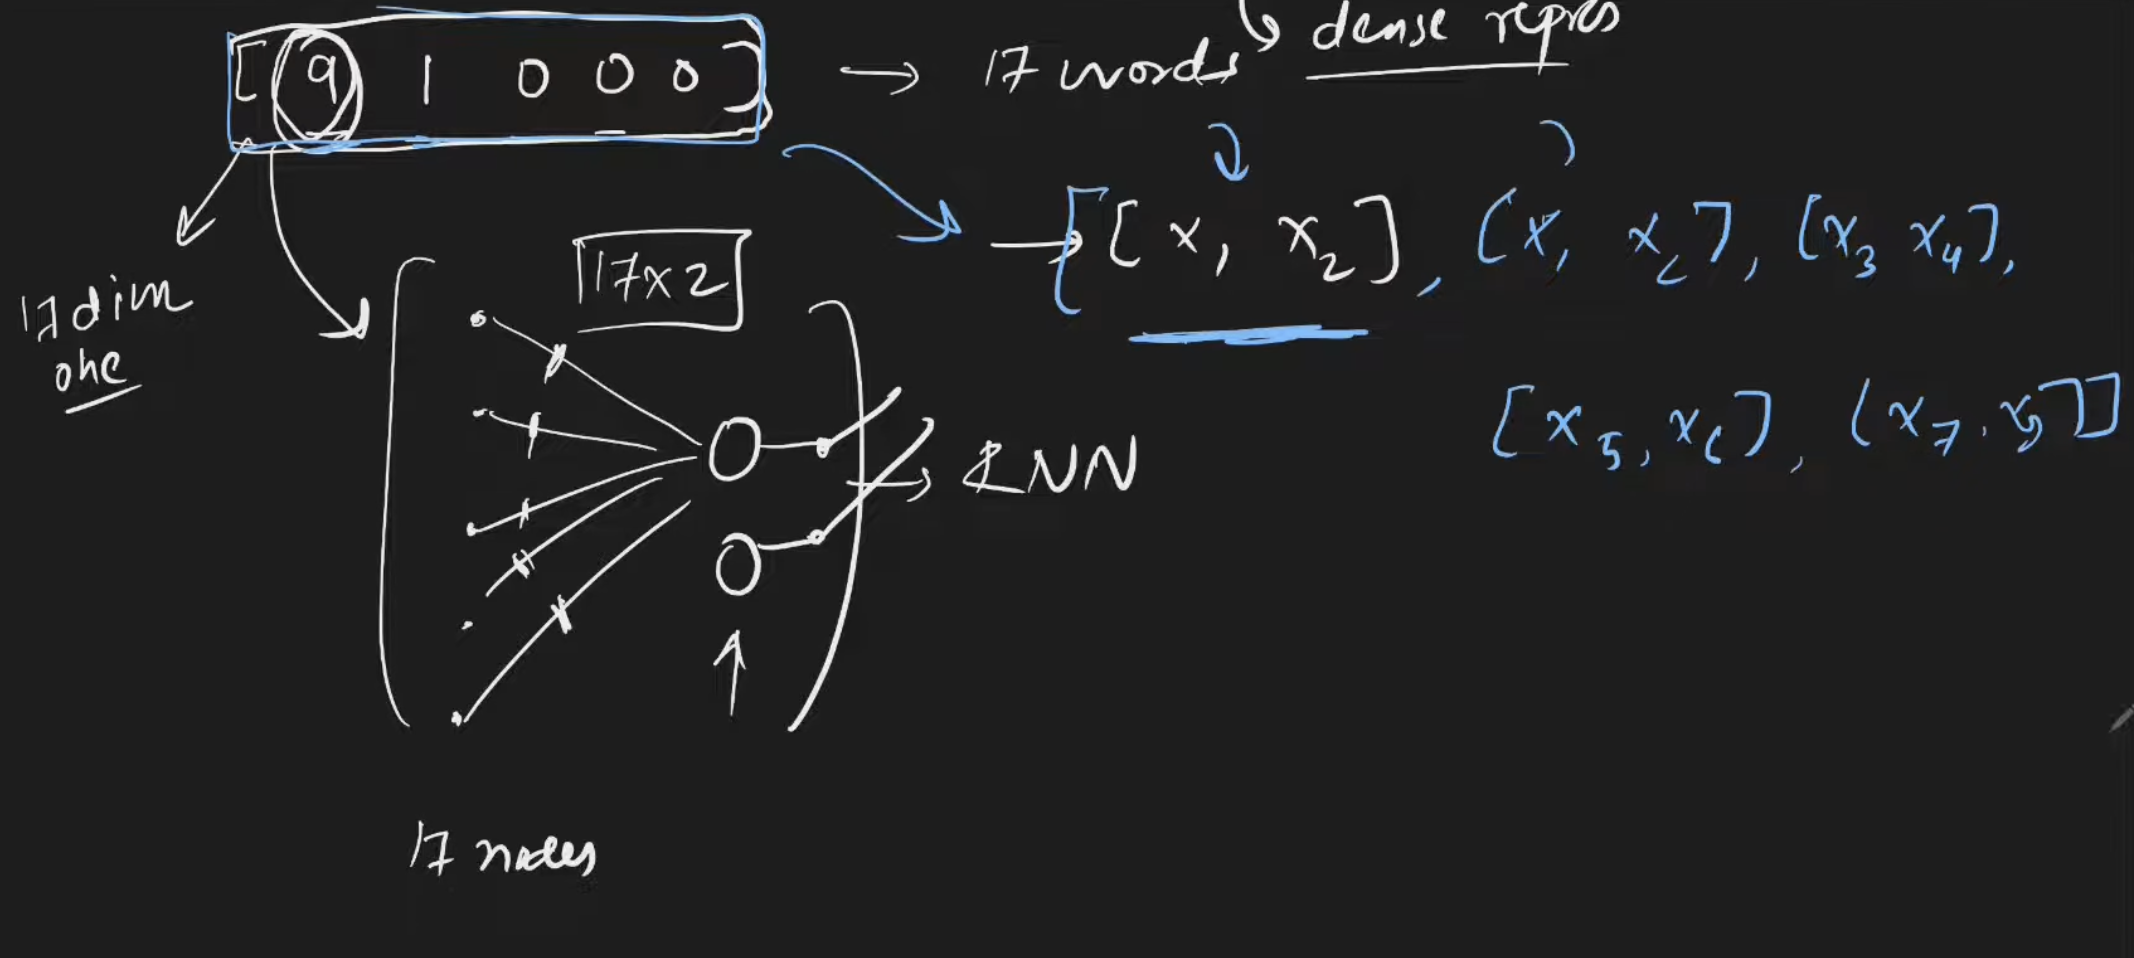

## the above picture is the embedding layer which output will be passed to RNN

In [14]:
model = Sequential()
model.add(Embedding(19,output_dim=2,input_length=5)) # adding embedding layer so that it can itself learn embeddings, 19 is used  because we need to make it vocabulary size (18) + 1

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile('adam','accuracy')

In [17]:
pred = model.predict(sequences) # will give 2 values for each word in a review/sentence
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[[ 0.00956871  0.02429534]
  [-0.02201091  0.0180846 ]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651]]

 [[-0.02201091  0.0180846 ]
  [-0.02201091  0.0180846 ]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651]]

 [[-0.00465841 -0.04880767]
  [-0.00465841 -0.04880767]
  [ 0.0178729   0.03550141]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651]]

 [[ 0.02900385  0.01827018]
  [-0.04288887  0.01659182]
  [ 0.02900385  0.01827018]
  [-0.02201091  0.0180846 ]
  [ 0.02900385  0.01827018]]

 [[ 0.01001566 -0.0051585 ]
  [-0.03414302  0.0046091 ]
  [ 0.04165829 -0.0047806 ]
  [ 0.02060563  0.0028956 ]
  [-0.02965974  0.00252651]]

 [[ 0.04585817  0.00569405]
  [ 0.04585817  0.00569405]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651]]

 [[-0.02990488  0.02101216]
  [-0.02990488  0.02101216]
  [-0.02965974  0.00252651]
  [-0.02965974  0.00252651

## now we understand embedding layer , we will do complete flow  in  a real dataset

In [19]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten

In [ ]:
(X_train,y_train),(X_test,y_test) = imdb.load_data() # already preprocessed integer encoded data

In [22]:
X_train.shape

(25000,)

In [23]:
X_test.shape

(25000,)

In [24]:
X_train # every review is integer encoded already

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1

In [25]:
X_train[0] # first review

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 22665,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 21631,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 19193,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 10311,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 31050,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 12118,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5

In [26]:
len(X_train[0])

218

In [27]:
len(X_train[2])

141

## so there is length mismatch
- to solve this we will use padding

In [28]:
X_train = pad_sequences(X_train,padding='post',maxlen=50) # just remove maxlen when u do in real,for faster training  now we are just doing for first 50 words for every review
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [ ]:
X_train.shape # 50 words only taken from each review and integer encoded

(25000, 50)

In [30]:
X_train[0]

array([2071,   56,   26,  141,    6,  194, 7486,   18,    4,  226,   22,
         21,  134,  476,   26,  480,    5,  144,   30, 5535,   18,   51,
         36,   28,  224,   92,   25,  104,    4,  226,   65,   16,   38,
       1334,   88,   12,   16,  283,    5,   16, 4472,  113,  103,   32,
         15,   16, 5345,   19,  178,   32], dtype=int32)

### now we will make the model

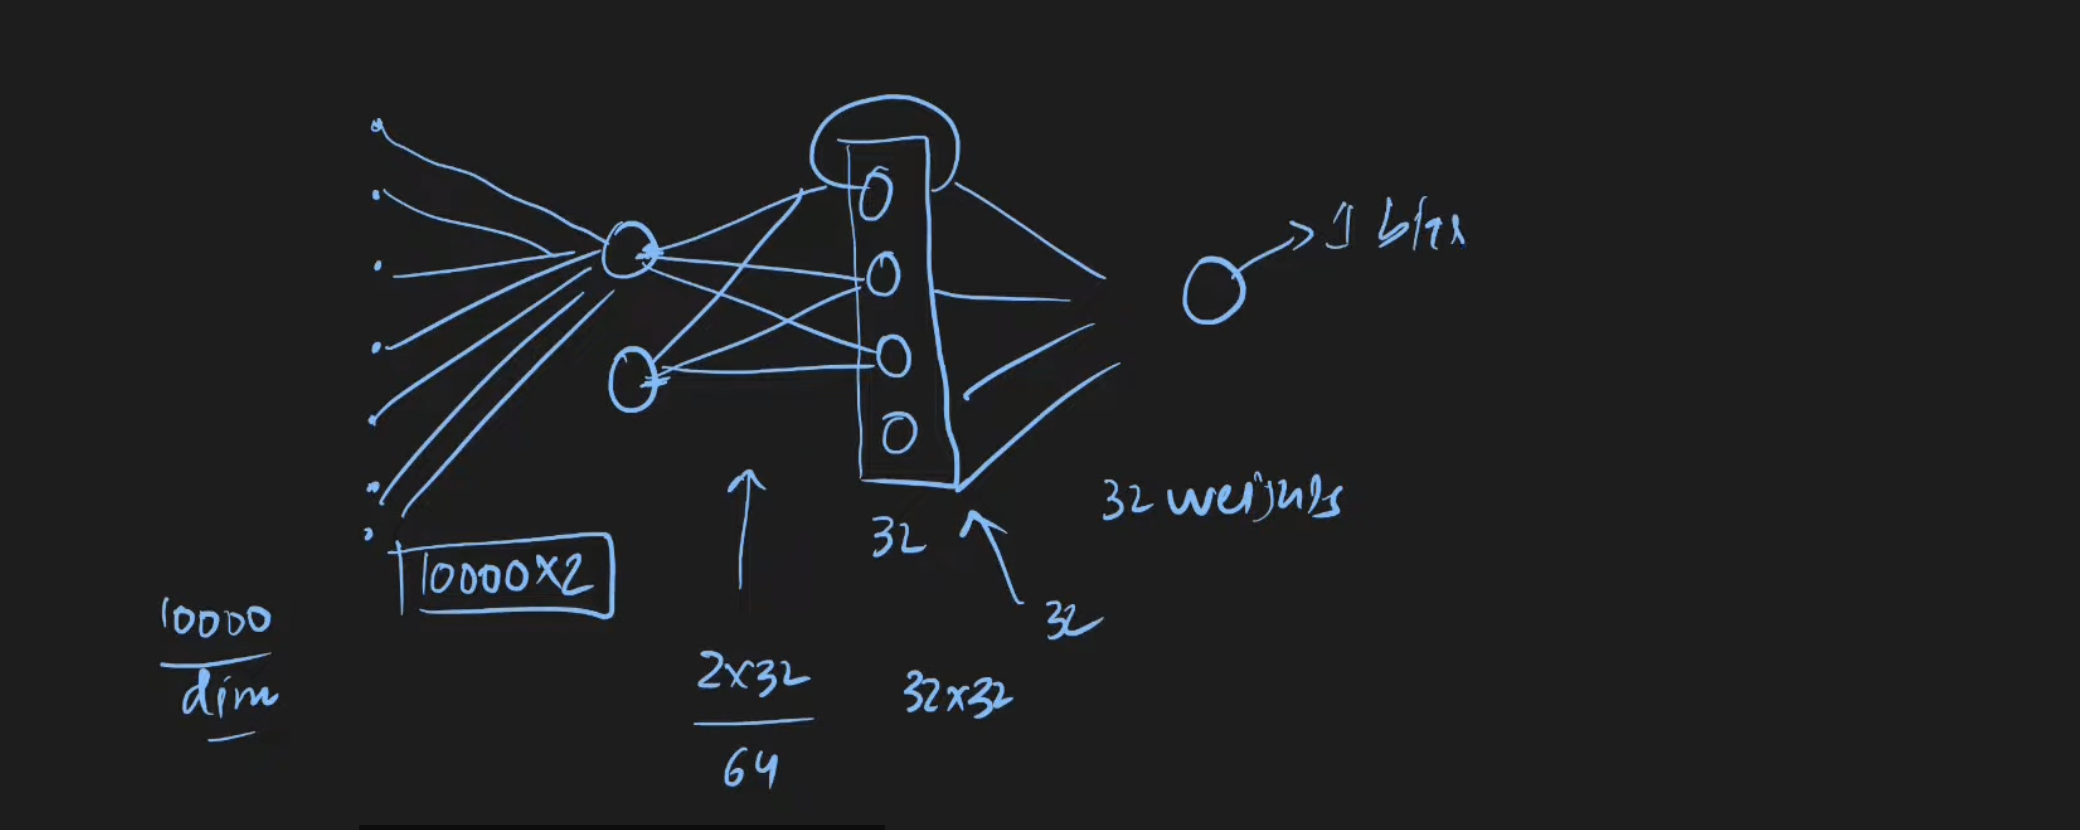

In [42]:
# Get the word index from IMDB dataset
word_index = imdb.get_word_index()

# Check vocabulary size
vocab_size = len(word_index) + 1  # +1 for padding (index 0)
print(f"Vocabulary size: {vocab_size}")

# Or check the maximum index in your data
max_index = max(np.max(X_train), np.max(X_test))
print(f"Maximum index in data: {max_index}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Vocabulary size: 88585
Maximum index in data: 88585


In [ ]:
model = Sequential()
model.add(Embedding(
    input_dim=88586,# Vocabulary size + 1(total unique words)
    output_dim=2,# Dimension of the dense vector
    input_length=50# Length of each sequence (number of words per review)
    ))
model.add(SimpleRNN(32,return_sequences=False)) # return_sequences =True only if u want to stack another RNN
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Understanding the Parameters (from transcript):**
In the example above, the total parameters are:
- Embedding layer: `88586 × 2 ` weights
- RNN layer: `2 × 32 + 32*32+32` weights (input_dim + hidden_dim) × units + bias
- Dense layer: `32*1 + 1` weights (from 32 RNN outputs to 1 output + bias)

In [44]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.6025 - loss: 0.6272 - val_acc: 0.7913 - val_loss: 0.4492
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8349 - loss: 0.3800 - val_acc: 0.8014 - val_loss: 0.4307
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8983 - loss: 0.2624 - val_acc: 0.8018 - val_loss: 0.4399
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.9286 - loss: 0.1940 - val_acc: 0.7915 - val_loss: 0.5868
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.9516 - loss: 0.1421 - val_acc: 0.7752 - val_loss: 0.6425


### 5. Code Examples

**Simple Example: Showing How Embedding Works**
```python
from keras.models import Sequential
from keras.layers import Embedding
import numpy as np

# Sample data: 2 reviews, each with 5 words, vocabulary size = 17
dummy_input = np.array([
    [1, 2, 3, 4, 5],   # Review 1
    [6, 7, 8, 9, 10]   # Review 2
])

# Create model with embedding layer
model = Sequential()
model.add(Embedding(input_dim=17, output_dim=2, input_length=5))

# Get the embedding vectors
output = model.predict(dummy_input)
print("Output shape:", output.shape)
print("Embedding for first word of first review:", output[0, 0, :])
print("Embedding for second word of first review:", output[0, 1, :])
```

**Output:**
```
Output shape: (2, 5, 2)
Embedding for first word of first review: [0.034, -0.021]
Embedding for second word of first review: [0.045, 0.008]
```
*Note: The actual numbers will be random because the model is not trained yet.*